In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn import preprocessing
from scipy.spatial.distance import pdist, squareform
from scipy import cluster
from matplotlib.lines import Line2D
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, homogeneity_score, completeness_score, v_measure_score
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score

# **Tarea 1: Validación Interna en DBSCAN.**

*   1.1. Amplía los apartados 2.3 y 2.5 de la práctica 5 para que, en cada uno de los gráficos
representados, el título incluya no solo el valor de eps, min_pts, el número de clústeres
obtenidos y el número de outliers detectados, sino también el coeficiente Silhouette y el
índice de Calinski-Harabasz correspondientes.

*   1.2. En un cuadro de texto, analiza los valores de ambas métricas obtenidos en las distintas
pruebas, poniendo especial atención en los valores correspondientes a la opción elegida como óptima en la Práctica 5, con respecto a las demás pruebas.

In [2]:
def generar_círculos_con_densidad_variable(radio_densidad_map, ruido=0.1):
# Genera círculos concéntricos con densidades variables.
#
# Args:
# radio_densidad_map (dict): Diccionario {radio: cantidad_de_puntos}
# ruido (float): Desviación estándar del ruido gaussiano.
#
# Returns:
# X (np.ndarray): Datos de forma (n_puntos, 2)
# y (np.ndarray): Etiquetas de clase (círculo) para cada punto
    np.random.seed(56)
    X = []
    y = []
    for i, (radio, n_puntos) in enumerate(radio_densidad_map.items()):
      angulos = np.random.uniform(0, 2 * np.pi, n_puntos)
      x = radio * np.cos(angulos) + np.random.normal(0, ruido, n_puntos)
      y_ = radio * np.sin(angulos) + np.random.normal(0, ruido, n_puntos)
      X.extend(zip(x, y_))
      y.extend([i] * n_puntos)
    return np.array(X), np.array(y)

# Configuración: círculo interior más denso, exterior menos denso
radio_densidad_map = {
 1: 1000, # círculo interior
 4: 750, # círculo medio
 7: 300 # círculo exterior
}

circulos, y = generar_círculos_con_densidad_variable(radio_densidad_map,
ruido=0.3)

# Crear DataFrame con columnas X, Y
df_circulos = pd.DataFrame(circulos, columns=['X', 'Y'])

# Calcular la distancia euclídea al origen y añadirla como nueva columna
df_circulos['distancia'] = np.sqrt(df_circulos['X']**2 + df_circulos['Y']**2)

# Mostrar las primeras filas del DataFrame
print(df_circulos.head())

          X         Y  distancia
0  0.695087  0.211759   0.726628
1 -0.233626  0.959980   0.987999
2 -0.499010 -0.351201   0.610207
3  0.695363  0.829677   1.082541
4 -0.465488  0.654058   0.802790


Estadísticas descriptivas de los circulos:
                 X            Y    distancia
count  2050.000000  2050.000000  2050.000000
mean      0.001066     0.022289     2.990412
std       2.613061     2.611980     2.168893
min      -7.713997    -7.549423     0.117734
25%      -1.020480    -1.054298     1.032857
50%       0.052334     0.049118     3.418525
75%       1.044572     1.114056     4.177602
max       7.571986     7.532232     7.851310




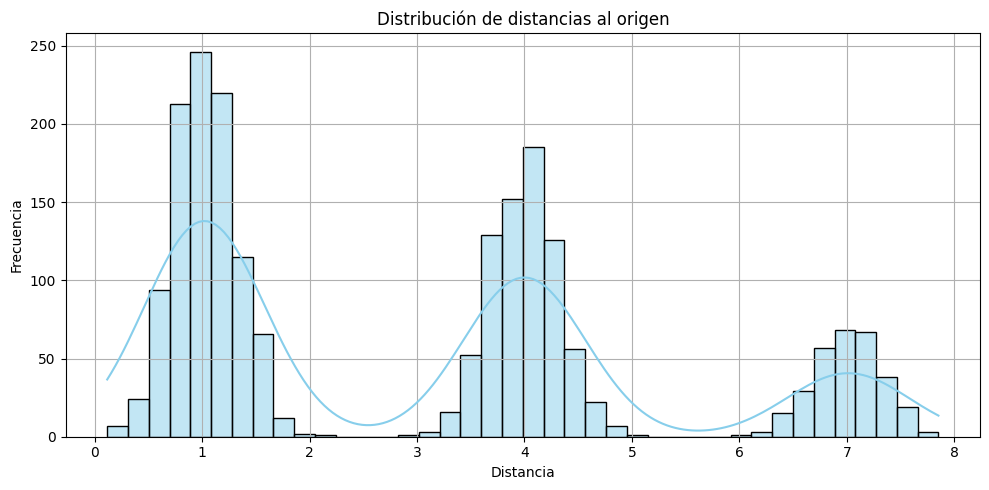

In [3]:
# Estadísticas descriptivas
print("Estadísticas descriptivas de los circulos:")
print(df_circulos.describe())
print("\n")

# Gráfico estadístico: distribución de distancias
plt.figure(figsize=(10, 5))
sns.histplot(df_circulos['distancia'], bins=40, kde=True, color='skyblue', edgecolor='black')
plt.title("Distribución de distancias al origen")
plt.xlabel("Distancia")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()



* El histograma presenta tres agrupaciones principales, que corresponden a los radios especificados en el dataset: aproximadamente en 1, 4 y 7 unidades de distancia al origen.

* Cada pico representa un grupo de puntos alrededor de uno de esos radios, es decir, los tres círculos generados.

* El pico más alto se encuentra cerca del radio 1, lo cual es coherente con que ese círculo tiene la mayor cantidad de puntos (1000).

* El segundo pico se encuentra cerca del radio 4, es un poco más bajo, correspondiente al círculo medio con 750 puntos.

* El pico más bajo se encuentra cerca del radio 7, representa el círculo externo, que tiene solo 300 puntos.

In [4]:
# Rango de valores
eps_values = [0.3, 0.5, 0.7, 0.9, 1.1, 1.3]
min_pts_values = [2, 3, 5, 7]

# Almacenar resultados
resultados = []

# Ejecutar DBSCAN para cada combinación
for eps in eps_values:
    for min_pts in min_pts_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_pts)
        etiquetas = dbscan.fit_predict(circulos)

        n_clusters = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
        n_outliers = list(etiquetas).count(-1)

        resultados.append({
            'eps': eps,
            'min_pts': min_pts,
            'n_clusters': n_clusters,
            'n_outliers': n_outliers
        })

# Crear DataFrame resumen
df_resultados = pd.DataFrame(resultados)

In [5]:
# Mostrar resultados
df_resultados.head()

,eps,min_pts,n_clusters,n_outliers
0,0.3,2,64,96
1,0.3,3,37,150
2,0.3,5,13,296
3,0.3,7,10,383
4,0.5,2,17,14


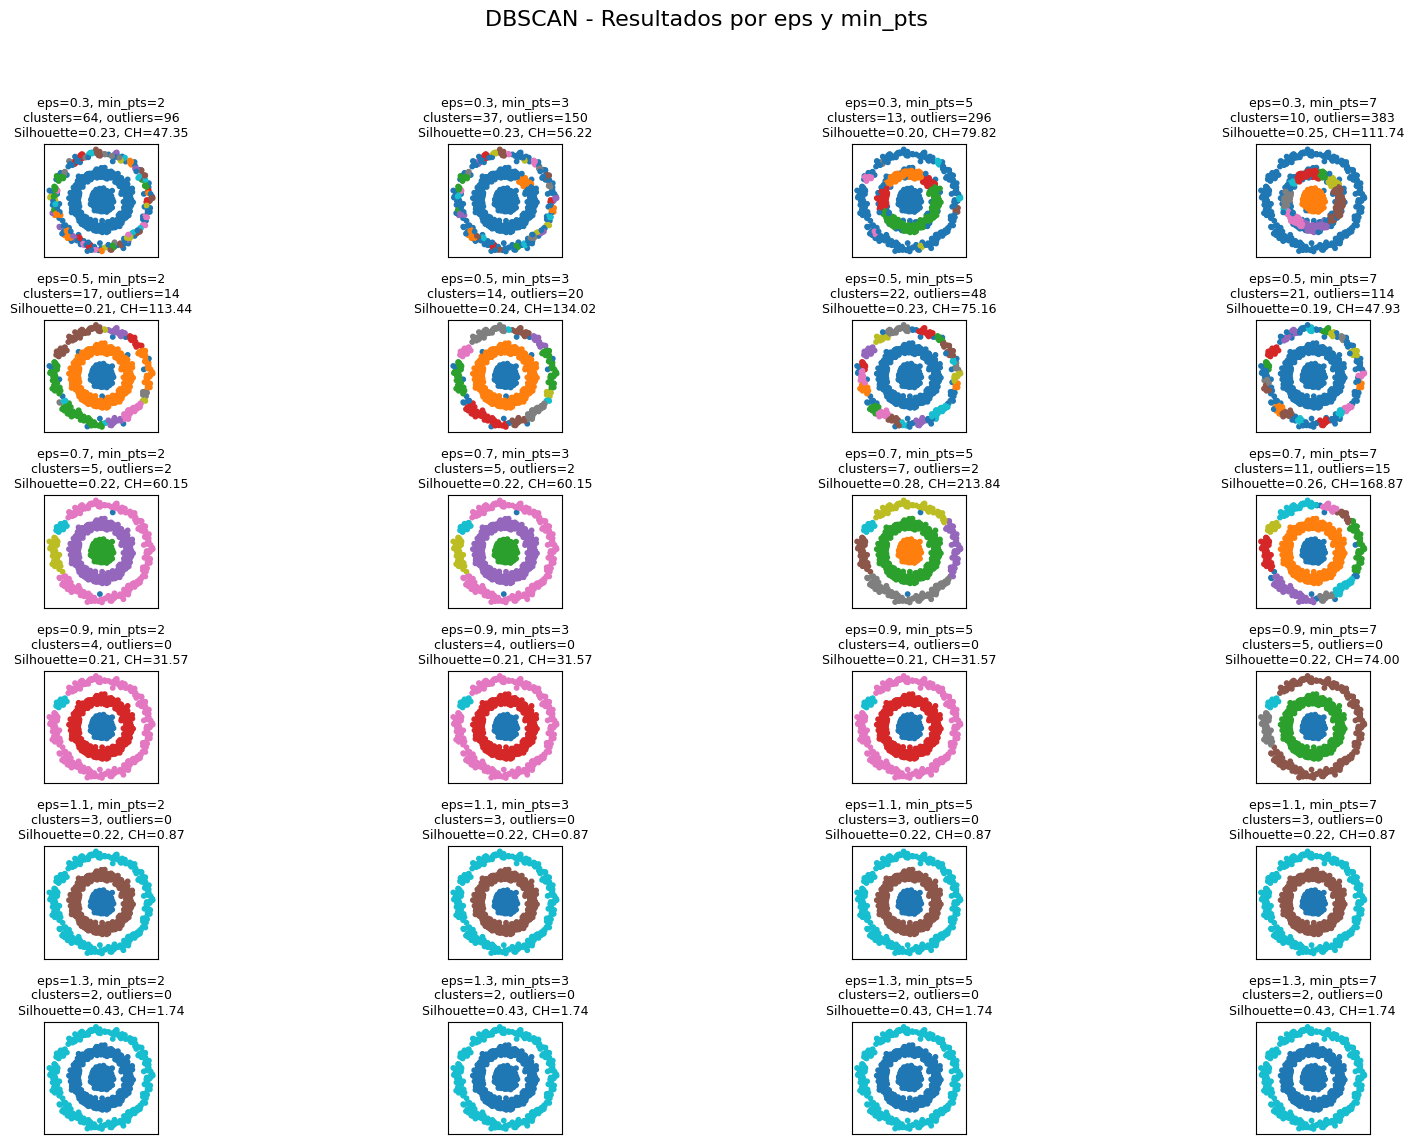

In [6]:
# 1.1. Amplía los apartados 2.3 y 2.5 de la práctica 5 para que, en cada uno de los gráficos representados,
# el título incluya no solo el valor de eps, min_pts, el número de clústeres obtenidos y el número de outliers detectados,
# sino también el coeficiente Silhouette y el índice de Calinski-Harabasz correspondientes.

# Crear figura de subplots
fig, axes = plt.subplots(len(eps_values), len(min_pts_values), figsize=(18, 12))
fig.suptitle("DBSCAN - Resultados por eps y min_pts", fontsize=16)

# Evaluación con visualización y métricas
for row_idx, eps in enumerate(eps_values):
    for col_idx, min_pts in enumerate(min_pts_values):
        db = DBSCAN(eps=eps, min_samples=min_pts)
        etiquetas = db.fit_predict(circulos)

        n_clusters = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
        n_outliers = list(etiquetas).count(-1)

        # Calcular métricas solo si hay al menos 2 clusters válidos
        if n_clusters >= 2:
            sil_score = silhouette_score(circulos, etiquetas)
            calinski = calinski_harabasz_score(circulos, etiquetas)
            extra_metrics = f"\nSilhouette={sil_score:.2f}, CH={calinski:.2f}"
        else:
            extra_metrics = "\nSilhouette=NA, CH=NA"

        ax = axes[row_idx, col_idx]
        scatter = ax.scatter(circulos[:, 0], circulos[:, 1], c=etiquetas, cmap="tab10", s=10)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(
            f"eps={eps}, min_pts={min_pts}\nclusters={n_clusters}, outliers={n_outliers}{extra_metrics}",
            fontsize=9
        )
        ax.grid(True)
        ax.set_aspect('equal')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


---
eps = 0.5 (fila 1) y eps = 0.7 (fila 2):

* Todos los valores de min_pts (2, 3, 5, 7) producen una cantidad excesiva de clústeres.

* El algoritmo tiende a sobreajustarse: se crean muchos grupos pequeños, reflejando una alta sensibilidad a pequeños cambios locales.
---
eps = 0.9 (fila 3):

* Se estabiliza el número de clústeres: 4 o 5 clústeres, sin outliers.

* Este valor de eps parece estar en un punto óptimo: detecta los círculos casi correctamente (puede dividir uno en dos por la variación en densidad).

* Resultados muy consistentes independientemente de min_pts.
---
eps = 1.1 (fila 4):

* Se detectan exactamente 3 clústeres en todos los casos, sin outliers.

* DBSCAN con eps=1.1 y cualquier min_pts >= 2 es el más preciso.
---
eps = 1.3 (fila 5):

* Solo se detectan 2 clústeres, lo que indica que los círculos más internos y medios han sido absorbidos en un único grupo.

* Es una muestra de sobreagrupamiento: al ampliar demasiado eps, DBSCAN une clústeres.
---

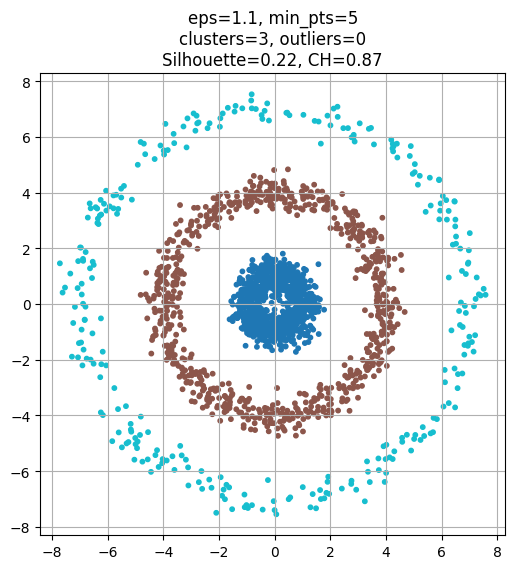

In [7]:
# DBSCAN con parámetros fijos
db = DBSCAN(eps=1.1, min_samples=5)
etiquetas = db.fit_predict(circulos)

n_clusters = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
n_outliers = list(etiquetas).count(-1)

# Calcular métricas si hay al menos 2 clusters válidos
if n_clusters >= 2:
    sil_score = silhouette_score(circulos, etiquetas)
    calinski = calinski_harabasz_score(circulos, etiquetas)
    extra_metrics = f"\nSilhouette={sil_score:.2f}, CH={calinski:.2f}"
else:
    extra_metrics = "\nSilhouette=NA, CH=NA"

# Gráfico
plt.figure(figsize=(6, 6))
plt.scatter(circulos[:, 0], circulos[:, 1], c=etiquetas, cmap="tab10", s=10)
plt.title(f"eps=1.1, min_pts=5\nclusters={n_clusters}, outliers={n_outliers}{extra_metrics}", fontsize=12)
plt.grid(True)
plt.axis("equal")
plt.show()

1.2. En un cuadro de texto, analiza los valores de ambas métricas obtenidos en las distintas
pruebas, poniendo especial atención en los valores correspondientes a la opción elegida
como óptima en la Práctica 5, con respecto a las demás pruebas.

---

Las métricas Silhouette y Calinski-Harabasz son útiles para evaluar la calidad de los clusters cuando estos son compactos y convexos, como sucede en agrupaciones esféricas. Sin embargo, en datasets con formas no convexas como los anillos, presentan limitaciones importantes.

En la configuración óptima (eps=1.1, min_pts=5), DBSCAN logra una segmentación perfecta de los tres anillos, pero con valores bajos de ambas métricas (Silhouette ≈ 0.22, CH ≈ 0.87), lo que no refleja la verdadera calidad del resultado. En cambio, otras configuraciones con métricas más altas generan resultados incorrectos con demasiados clusters o outliers.

Por tanto, estas métricas no nos sirven para evaluar los resultados de agrupaciones no convexas.

In [8]:
# Entrenamiento DBSCAN con los mejores hiperparámetros
db = DBSCAN(eps=1.1, min_samples=5)
etiquetas_dbscan = db.fit_predict(circulos)

# Añadir columna con etiquetas de los clústeres
df_circulos['dbscan'] = etiquetas_dbscan

In [9]:
# Círculo exterior (1000)
df_circulos[df_circulos['dbscan']==0]

,X,Y,distancia,dbscan
0,0.695087,0.211759,0.726628,0
1,-0.233626,0.959980,0.987999,0
2,-0.499010,-0.351201,0.610207,0
3,0.695363,0.829677,1.082541,0
4,-0.465488,0.654058,0.802790,0
...,...,...,...,...
995,-0.311064,-0.209427,0.374994,0
996,-0.402663,-0.406187,0.571949,0
997,0.737491,1.013127,1.253124,0
998,1.172178,0.332532,1.218433,0


In [10]:
# Círculo exterior (750)
df_circulos[df_circulos['dbscan']==1]

,X,Y,distancia,dbscan
1000,1.143743,4.156764,4.311246,1
1001,-1.618683,3.658211,4.000331,1
1002,1.417114,4.285614,4.513834,1
1003,-1.036468,-3.476345,3.627567,1
1004,3.926536,-0.950623,4.039972,1
...,...,...,...,...
1745,-0.982251,3.488653,3.624296,1
1746,-2.276856,3.047558,3.804166,1
1747,3.808459,0.878799,3.908535,1
1748,3.789489,0.817465,3.876658,1


In [11]:
# Círculo exterior (300)
df_circulos[df_circulos['dbscan']==2]

,X,Y,distancia,dbscan
1750,6.953661,-1.412135,7.095599,2
1751,-6.904104,-2.204094,7.247391,2
1752,-4.750487,-5.659757,7.389180,2
1753,4.886677,5.671852,7.486623,2
1754,0.058459,-7.549423,7.549650,2
...,...,...,...,...
2045,4.010475,-5.054344,6.452155,2
2046,-1.682426,7.046522,7.244586,2
2047,6.652698,-0.752570,6.695129,2
2048,-7.713997,1.461955,7.851310,2


# **Tarea 2: Validación Interna en el Algoritmo Jerárquico.**
* 2.1. Amplía el apartado 3.2 de la práctica 5 para que, en el gráfico que muestra el resultado con
el umbral seleccionado, la línea inferior incluya no solo el valor del umbral, sino también el
coeficiente Silhouette y el índice de Calinski-Harabasz correspondientes

* 2.2. En un cuadro de texto, analiza los valores de ambas métricas obtenidas.


<ipython-input-12-426ac785d438>:13: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  clusters = cluster.hierarchy.linkage(D, method='complete')


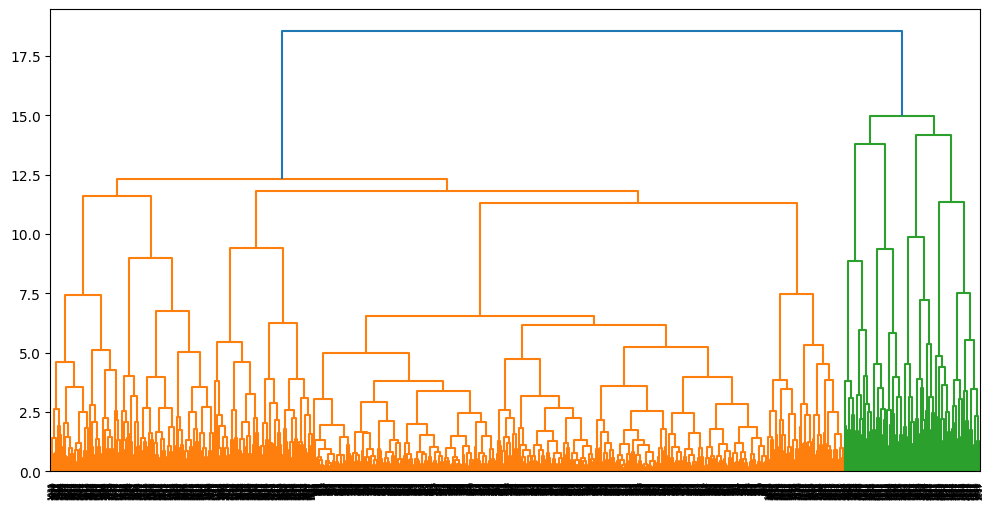

In [12]:
# Escalar
min_max_scaler = preprocessing.MinMaxScaler()
circulos_scaled = min_max_scaler.fit_transform(circulos)

## Clustering jerárquico
# Obtener la matriz de distancia entre todos los elementos
D = squareform(pdist(circulos_scaled, metric='euclidean'))
avD = np.average(D)

# Constuimos el dendograma
plt.figure(figsize=(12, 6))
# Seleccionamos como distancia intercluster el vecino más alejado (complete)
clusters = cluster.hierarchy.linkage(D, method='complete')
cluster.hierarchy.dendrogram(clusters, color_threshold=15)
plt.show()

In [13]:
# 2.1. Amplía el apartado 3.2 de la práctica 5 para que, en el gráfico que muestra el resultado con
# el umbral seleccionado, la línea inferior incluya no solo el valor del umbral, sino también el
# coeficiente Silhouette y el índice de Calinski-Harabasz correspondientes

# Obtenemos el grupo al que pertenece cada observación
threshold = 3
# grupos
grupos = cluster.hierarchy.fcluster(clusters, threshold, criterion='maxclust')
# Número de clusters
print("Número de clusters {}".format(len(set(grupos))))
grupos

Número de clusters 3


array([1, 1, 1, ..., 2, 3, 2], dtype=int32)

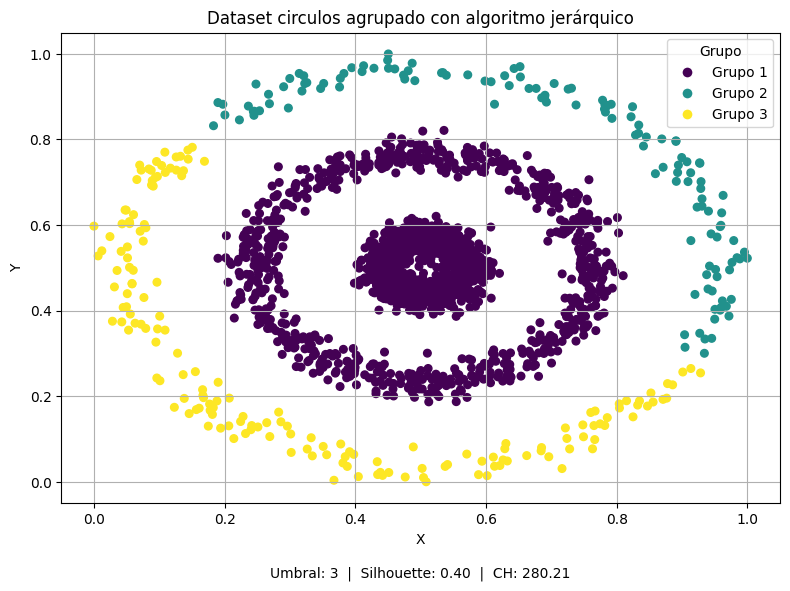

In [14]:
# Calcular métricas
sil_score = silhouette_score(circulos_scaled, grupos)
ch_score = calinski_harabasz_score(circulos_scaled, grupos)

plt.figure(figsize=(8, 6))

# Crear scatter plot y guardar el objeto para acceder al cmap y norm
scatter = plt.scatter(
    circulos_scaled[:, 0],
    circulos_scaled[:, 1],
    c=grupos,
    cmap='viridis',
    s=30
)

# Título y etiquetas
plt.title('Dataset circulos agrupado con algoritmo jerárquico')
plt.xlabel('X')
plt.ylabel('Y')

unique_groups = np.unique(grupos)
colors = scatter.cmap(scatter.norm(unique_groups))

# Crear leyenda
legend_elements = [Line2D([0], [0], marker='o', color='w', label=f'Grupo {g}',
                          markerfacecolor=c, markersize=8)
                   for g, c in zip(unique_groups, colors)]

plt.legend(handles=legend_elements, title="Grupo", loc='upper right')

# Mostrar el umbral + métricas abajo como texto
plt.text(0.5, -0.15,
         f'Umbral: {threshold}  |  Silhouette: {sil_score:.2f}  |  CH: {ch_score:.2f}',
         ha='center', va='center', transform=plt.gca().transAxes)

plt.grid(True)
plt.tight_layout()
plt.show()


In [15]:
df_circulos['jerarquico'] = grupos
df_circulos

,X,Y,distancia,dbscan,jerarquico
0,0.695087,0.211759,0.726628,0,1
1,-0.233626,0.959980,0.987999,0,1
2,-0.499010,-0.351201,0.610207,0,1
3,0.695363,0.829677,1.082541,0,1
4,-0.465488,0.654058,0.802790,0,1
...,...,...,...,...,...
2045,4.010475,-5.054344,6.452155,2,3
2046,-1.682426,7.046522,7.244586,2,2
2047,6.652698,-0.752570,6.695129,2,2
2048,-7.713997,1.461955,7.851310,2,3


2.2. En un cuadro de texto, analiza los valores de ambas métricas obtenidas.

---
Dado que el algoritmo jerárquico no utiliza información previa sobre la forma de los datos, en algunos casos los bordes de los clusters no son perfectamente definidos y hay cierta mezcla de puntos entre grupos contiguos.

Al igual que con DBSCAN, estas métricas no nos sirven para evaluar los resultados de agrupaciones no convexas. El algoritmo jerárquico no logra una segmentación perfecta de los tres anillos y da valores más altos que los de DBSCAN de ambas métricas (Silhouette ≈ 0.40, CH ≈ 280.21), lo que no refleja la realidad del resultado.

# **Tarea 3: Validación Interna en KMeans con truco de núcleo.**
* 3.1. Amplía los apartados 4.2 y 4.3 de la práctica 5 para que, en cada uno de los gráficos
representados, en su parte inferior se incluya no solo los valores de los centroides, sino
también el coeficiente Silhouette y el índice de Calinski-Harabasz correspondientes.
* 3.2. En un cuadro de texto, analiza los valores de ambas métricas obtenidos en las distintas
pruebas, poniendo especial atención en los valores correspondientes a la opción elegida
como óptima en la Práctica 5, con respecto a las demás pruebas

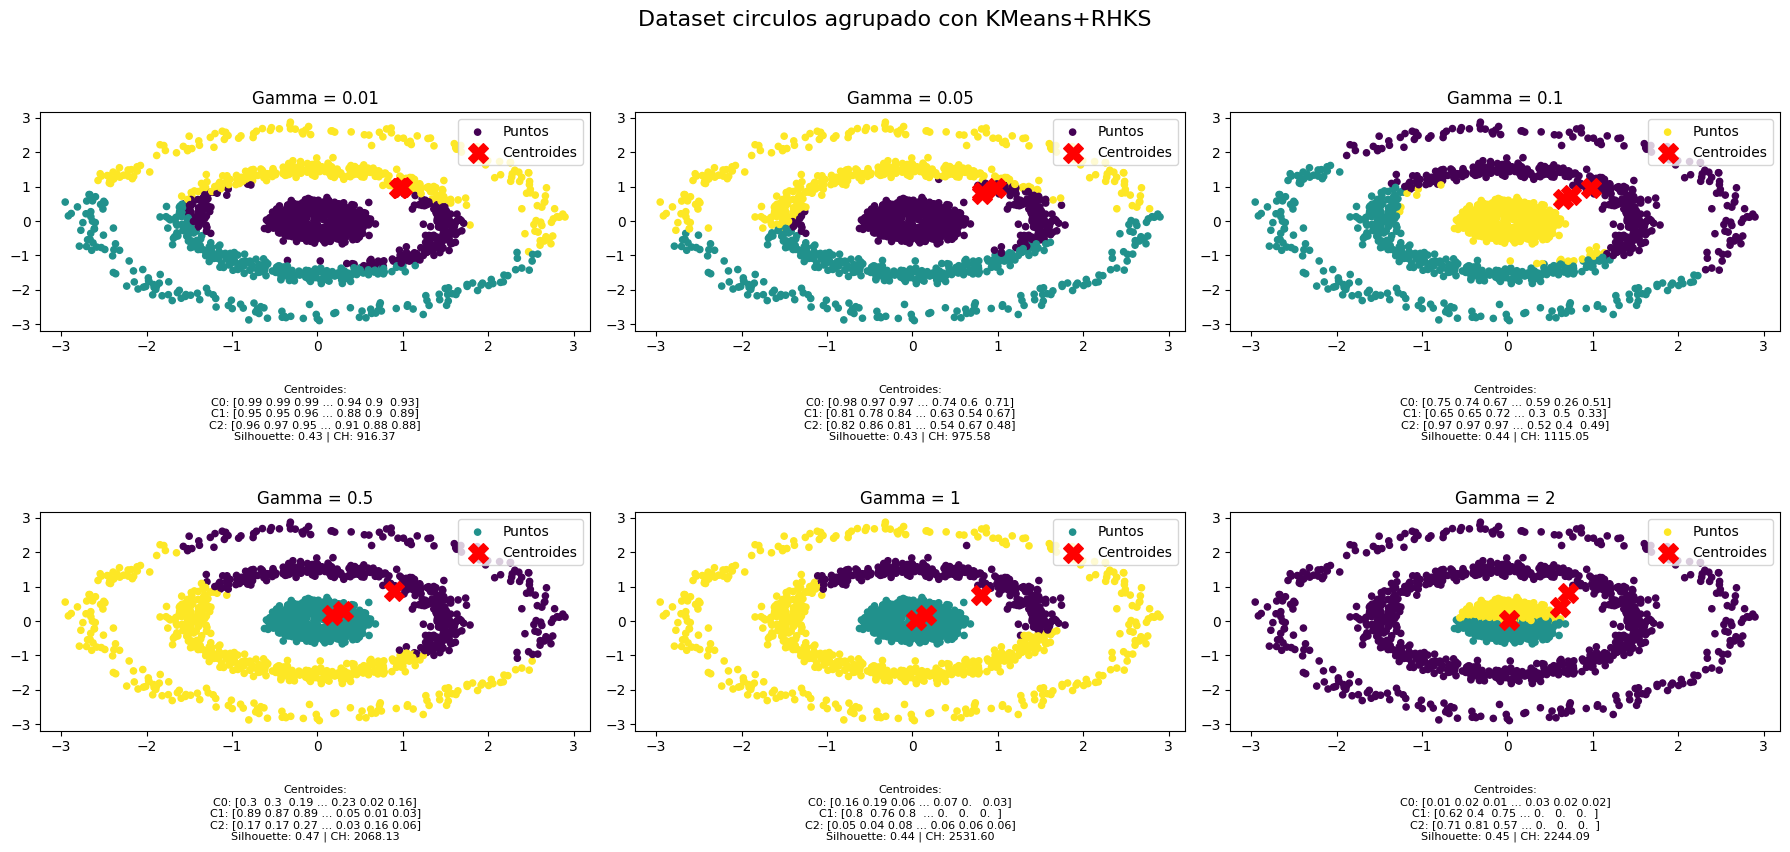

In [16]:
# 3.1. Amplía los apartados 4.2 y 4.3 de la práctica 5 para que,
# en cada uno de los gráficos representados, en su parte inferior se incluya no solo los valores de los centroides,
#sino también el coeficiente Silhouette y el índice de Calinski-Harabasz correspondientes.

# Escalar el dataset
scaler = preprocessing.StandardScaler()
circulos_standard_scaled = scaler.fit_transform(circulos)

# Prueba con distintos valores de gamma
gammas = [0.01, 0.05, 0.1, 0.5, 1, 2]
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
axs = axs.ravel()

for i, gamma in enumerate(gammas):
    K = rbf_kernel(circulos_standard_scaled, gamma=gamma)

    kmeans = KMeans(n_clusters=3, random_state=0)
    kmeans.fit(K)

    labels = kmeans.labels_
    centroids = kmeans.cluster_centers_

    # Calcular métricas
    sil_score = silhouette_score(K, labels)
    ch_score = calinski_harabasz_score(K, labels)

    axs[i].scatter(circulos_standard_scaled[:, 0], circulos_standard_scaled[:, 1], c=labels, cmap='viridis', s=20, label='Puntos')
    axs[i].scatter(centroids[:, 0], centroids[:, 1], marker='X', c='red', s=200, label='Centroides')
    axs[i].set_title(f"Gamma = {gamma}")
    axs[i].legend(loc='upper right')

    centroid_text = "\n".join([f"C{j}: {np.round(c, 2)}" for j, c in enumerate(centroids)])
    axs[i].text(0.5, -0.25,
                f"Centroides:\n{centroid_text}\nSilhouette: {sil_score:.2f} | CH: {ch_score:.2f}",
                ha='center', va='top', transform=axs[i].transAxes, fontsize=8)

plt.suptitle("Dataset circulos agrupado con KMeans+RHKS", fontsize=16)
plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

In [17]:
# Usar un valor específico de gamma para generar columna en el DataFrame
# Usamos gamma=1 como ejemplo
gamma_final = 0.1
K_final = rbf_kernel(circulos_standard_scaled, gamma=gamma_final)
kmeans_final = KMeans(n_clusters=3, random_state=0)
df_circulos['KMeansRHKS'] = kmeans_final.fit_predict(K_final)

df_circulos

,X,Y,distancia,dbscan,jerarquico,KMeansRHKS
0,0.695087,0.211759,0.726628,0,1,2
1,-0.233626,0.959980,0.987999,0,1,2
2,-0.499010,-0.351201,0.610207,0,1,2
3,0.695363,0.829677,1.082541,0,1,2
4,-0.465488,0.654058,0.802790,0,1,2
...,...,...,...,...,...,...
2045,4.010475,-5.054344,6.452155,2,3,1
2046,-1.682426,7.046522,7.244586,2,2,0
2047,6.652698,-0.752570,6.695129,2,2,0
2048,-7.713997,1.461955,7.851310,2,3,1


3.2. En un cuadro de texto, analiza los valores de ambas métricas obtenidos en las distintas
pruebas, poniendo especial atención en los valores correspondientes a la opción elegida
como óptima en la Práctica 5, con respecto a las demás pruebas

---

Al observar los resultados con distintas gammas, notamos que tanto el coeficiente de Silhouette como el índice de Calinski-Harabasz (CH) tienden a mejorar conforme gamma aumenta, especialmente a partir de gamma = 0.5. Dando unos resultados de CH muy buenos.

Aún así, nos encontramos con el mismo problema que con el algoritmo jerárquico, no logra una segmentación perfecta de los tres anillos y da valores más altos que los de DBSCAN de ambas métricas, por lo que no refleja la realidad de la mala agrupación de los anillos.

# **Tarea 4: Validación Externa entre algoritmos.**
Tras completar todos los agrupamientos descritos en la Práctica 5, el dataframe df_circulos contiene
las siguientes columnas: X, Y, distancia, dbscan, jerarquico, KMeansRHKS.

* 4.1. A partir del dataframe df_circulos, realiza una validación externa de los resultados de
agrupamiento utilizando todas las métricas vistas en clase: Rand Index ajustado (ARI),
homogeneidad, exhaustividad, V-Score, NMI y AMI. La comparación se llevará a cabo de
forma pareada, evaluando las coincidencias entre los siguientes pares de algoritmos:
DBSCAN vs KMeans, DBSCAN vs Jerárquico y KMeans vs Jerárquico.

* 4.2. Los resultados obtenidos deben almacenarse en un nuevo dataframe, de nombre
df_validacion_ext, donde cada fila represente una comparación entre dos métodos de
agrupamiento, con las columnas siguientes:
 * Comparación: Nombre de los algoritmos comparados (por ejemplo, "DBSCAN vs
KMeansRHKS")
 * ARI
 * Homogeneidad
 * Exhaustividad
 * V-Score
 * NMI
 * AMI

* 4.3. Genera un gráfico de barras agrupado que muestre los valores de cada métrica para cada
comparación.
* 4.4. En un bloque de texto, incluye un análisis pormenorizado de los resultados obtenidos en la
validación externa.


In [18]:
# 4.1. A partir del dataframe df_circulos, realiza una validación externa de los resultados de
# agrupamiento utilizando todas las métricas vistas en clase: Rand Index ajustado (ARI),
# homogeneidad, exhaustividad, V-Score, NMI y AMI. La comparación se llevará a cabo de
# forma pareada, evaluando las coincidencias entre los siguientes pares de algoritmos:
# DBSCAN vs KMeans, DBSCAN vs Jerárquico y KMeans vs Jerárquico.

# Diccionario para almacenar resultados
resultados = []

pares = [
    ("DBSCAN vs KMeansRHKS", 'dbscan', 'KMeansRHKS'),
    ("DBSCAN vs Jerarquico", 'dbscan', 'jerarquico'),
    ("KMeansRHKS vs Jerarquico", 'KMeansRHKS', 'jerarquico')
]

# Calcular métricas
for nombre, col1, col2 in pares:
    etiquetas1 = df_circulos[col1].values
    etiquetas2 = df_circulos[col2].values

    resultados.append({
        "Comparación": nombre,
        "ARI": adjusted_rand_score(etiquetas1, etiquetas2),
        "Homogeneidad": homogeneity_score(etiquetas1, etiquetas2),
        "Exhaustividad": completeness_score(etiquetas1, etiquetas2),
        "V-Score": v_measure_score(etiquetas1, etiquetas2),
        "NMI": normalized_mutual_info_score(etiquetas1, etiquetas2),
        "AMI": adjusted_mutual_info_score(etiquetas1, etiquetas2)
    })

resultados

[{'Comparación': 'DBSCAN vs KMeansRHKS',
  'ARI': 0.692668659603956,
  'Homogeneidad': np.float64(0.6400776950801021),
  'Exhaustividad': np.float64(0.6153961616726455),
  'V-Score': np.float64(0.6274943195446301),
  'NMI': np.float64(0.62749431954463),
  'AMI': np.float64(0.6271367471521857)},
 {'Comparación': 'DBSCAN vs Jerarquico',
  'ARI': 0.33315222349727913,
  'Homogeneidad': np.float64(0.4166099023457569),
  'Exhaustividad': np.float64(0.8061126868195042),
  'V-Score': np.float64(0.5493225212512346),
  'NMI': np.float64(0.5493225212512346),
  'AMI': np.float64(0.5487379859986963)},
 {'Comparación': 'KMeansRHKS vs Jerarquico',
  'ARI': 0.16479738665190807,
  'Homogeneidad': np.float64(0.20100609893725147),
  'Exhaustividad': np.float64(0.404532401983866),
  'V-Score': np.float64(0.2685658464087836),
  'NMI': np.float64(0.26856584640878356),
  'AMI': np.float64(0.267642555551261)}]

In [19]:
# 4.2. Los resultados obtenidos deben almacenarse en un nuevo dataframe, de nombre
# df_validacion_ext, donde cada fila represente una comparación entre dos métodos de
# agrupamiento.

df_validacion_ext = pd.DataFrame(resultados)
df_validacion_ext

,Comparación,ARI,Homogeneidad,Exhaustividad,V-Score,NMI,AMI
0,DBSCAN vs KMeansRHKS,0.692669,0.640078,0.615396,0.627494,0.627494,0.627137
1,DBSCAN vs Jerarquico,0.333152,0.416610,0.806113,0.549323,0.549323,0.548738
2,KMeansRHKS vs Jerarquico,0.164797,0.201006,0.404532,0.268566,0.268566,0.267643


<Figure size 1400x700 with 0 Axes>

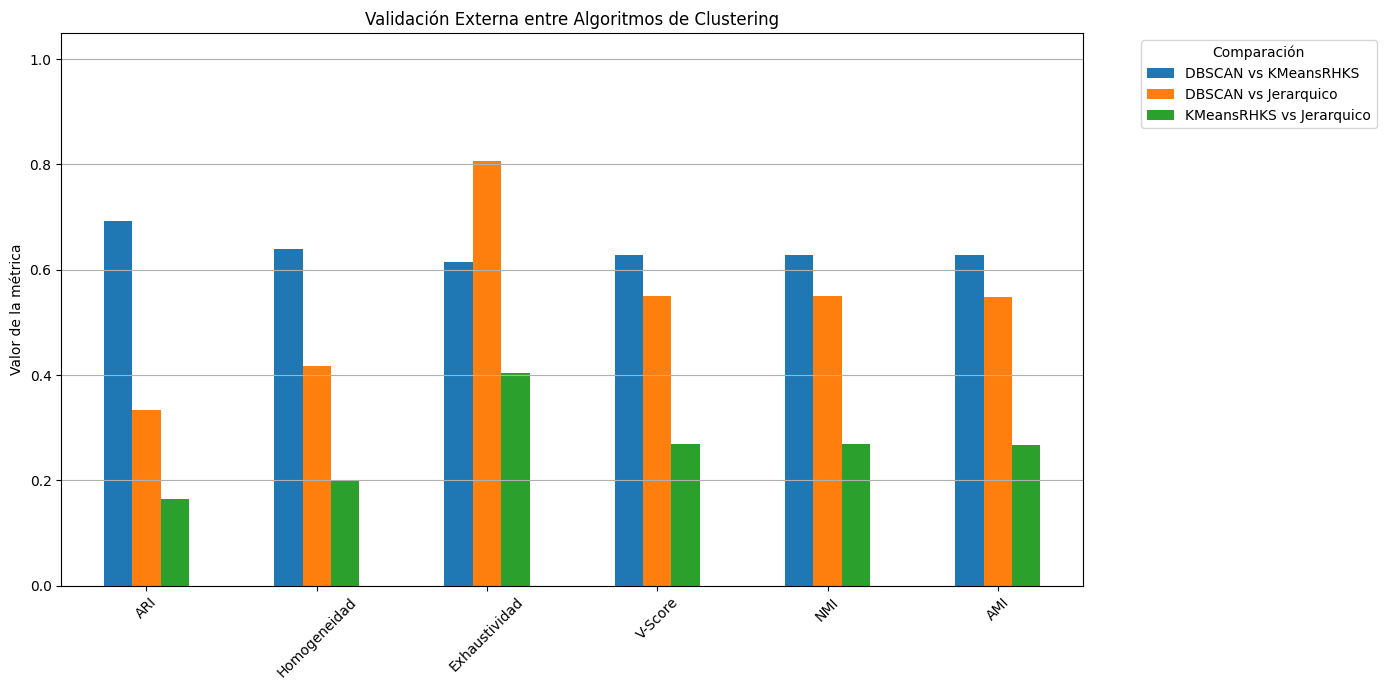

In [20]:
# 4.3. Genera un gráfico de barras agrupado que muestre los valores de cada métrica para cada
# comparación.

df_plot = df_validacion_ext.set_index('Comparación').T

plt.figure(figsize=(14, 7))
df_plot.plot(kind='bar', figsize=(14, 7), rot=0)
plt.title("Validación Externa entre Algoritmos de Clustering")
plt.ylabel("Valor de la métrica")
plt.xticks(rotation=45)
plt.legend(title="Comparación", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y')
plt.ylim(0, 1.05)  # Ajuste del eje Y para mostrar claramente el máximo
plt.tight_layout()
plt.show()

4.4. En un bloque de texto, incluye un análisis pormenorizado de los resultados obtenidos en la
validación externa.

---

Los valores más altos en todas las métricas se observan en la comparación DBSCAN vs KMeansRHKS, lo cual indica que ambos algoritmos generan particiones muy similares. Esto es coherente con la naturaleza del dataset, compuesto por tres anillos no linealmente separables, ya que tanto DBSCAN como KMeans+RHKS son capaces de adaptarse a formas no esféricas.

La comparación DBSCAN vs Jerárquico muestra valores intermedios. En este caso, parece que aunque detecta cierta estructura similar a DBSCAN, no logra una coincidencia tan alta.

La comparación KMeansRHKS vs Jerárquico obtiene los valores más bajos en todas las métricas. Esto sugiere que estos dos métodos producen particiones muy diferentes.

Así pues, el análisis de validación externa refleja claramente qué algoritmos son más consistentes entre sí en la identificación de la estructura del dataset, siendo DBSCAN y KMeansRHKS los más adecuados para este tipo de datos no lineales y de forma circular.